In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import os

In [3]:

# Load your ORCESTRA Level-4 dataset
# (Replace the path below with the actual location of your data file)
# 1. SETUP & LOAD DATA
os.environ["IPFS_GATEWAY"] = "https://ipfs.io"
data_url = "ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i"
print(f"Attempting to access data from: {data_url}")

try:
    ds = xr.open_dataset(data_url, engine="zarr")
    print("Dataset successfully loaded!\n")
except Exception as e:
    print(f"Error loading dataset: {e}")

Attempting to access data from: ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i
Dataset successfully loaded!



In [4]:

# Clean previous categorization variables to avoid confusion
vars_to_remove = ['category', 'category_trimodal', 'category_bimodal']
ds = ds.drop_vars(vars_to_remove, errors='ignore')

# Constants for the Li & Singh (2025) Method
P_SFC = 1000.0  # Surface Pressure (hPa)
P_TOP = 100.0   # Tropopause Pressure (hPa)

In [5]:
res_angle = []
res_evolutionary = []
res_avg_check = [] 

# Define the mid-point for the average method (Standard is 550 hPa)
P_MID = 550.0 

for c in ds.circle.values:
    omega = ds['omega'].sel(circle=c).values
    p = ds['p_mean'].sel(circle=c).values / 100 # Convert Pa to hPa
    
    # 1. Filter: Missing Data
    if np.isnan(omega).all():
        res_angle.append(np.nan)
        res_evolutionary.append("Missing Data")
        res_avg_check.append("Missing Data")
        continue
        
    # 2. Filter: Suppressed/Weak background (Min Omega > -0.05 Pa/s)
    if np.nanmin(omega) > -0.05:
        res_angle.append(np.nan)
        res_evolutionary.append("Suppressed / Weak")
        res_avg_check.append("Suppressed / Weak")
        continue

    # --- Method 1: Singh & Li (2025) Evolutionary Angle ---
    mask = ~np.isnan(omega) & ~np.isnan(p)
    o_v, p_v = -omega[mask], p[mask] 
    
    p_star = (p_v - P_TOP) / (P_SFC - P_TOP)
    m1 = np.sin(np.pi * p_star)
    m2 = np.sin(2 * np.pi * p_star)
    
    # Using np.trapezoid for NumPy 2.0+ compatibility
    c1 = np.trapezoid(o_v * m1, p_v)
    c2 = np.trapezoid(o_v * m2, p_v)
    angle = np.degrees(np.arctan2(c2, c1)) 
    res_angle.append(angle)
    
    if angle > 45:
        res_evolutionary.append("Top-Heavy (Stratiform Decay)")
    else:
        res_evolutionary.append("Bottom-Heavy (Convective Decay)")

    # --- Method 2: Upper vs Lower Average ---
    # We compare the mean intensity. Smaller (more negative) means stronger ascent.
    upper_mask = (p > P_TOP) & (p < P_MID)
    lower_mask = (p >= P_MID) & (p < P_SFC)
    
    # Calculate means, ignoring NaNs within the profile
    avg_upper = np.nanmean(omega[upper_mask])
    avg_lower = np.nanmean(omega[lower_mask])
    
    if avg_upper < avg_lower:
        # Omega is more negative in the upper layer
        res_avg_check.append("Top-Heavy (Average Method)")
    else:
        # Omega is more negative in the lower layer
        res_avg_check.append("Bottom-Heavy (Average Method)")

# Save results into the dataset
ds['top_heaviness_angle'] = (('circle'), res_angle)
ds['category_evolutionary'] = (('circle'), res_evolutionary)
ds['category_avg'] = (('circle'), res_avg_check)

print("Comparison of Categorization Methods:")
print("-" * 30)
print("Singh & Li (2025) Angle Method:")
print(pd.Series(res_evolutionary).value_counts())
print("\nFixed Average Method (Upper vs Lower):")
print(pd.Series(res_avg_check).value_counts())

Comparison of Categorization Methods:
------------------------------
Singh & Li (2025) Angle Method:
Bottom-Heavy (Convective Decay)    33
Top-Heavy (Stratiform Decay)       32
Suppressed / Weak                  22
Missing Data                        2
Name: count, dtype: int64

Fixed Average Method (Upper vs Lower):
Bottom-Heavy (Average Method)    36
Top-Heavy (Average Method)       29
Suppressed / Weak                22
Missing Data                      2
Name: count, dtype: int64


In [6]:
ds

<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B ...
    circle_lon                (circle) float32 356B ...
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B ...
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB ...
Dimensions without coordinates: circle, sonde
Data variables: (12/76)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde, altitude) float32 6MB ...
    y                         (sonde, altitude) float32 6MB ...
    top_heaviness_angle       (circle) float64 712B 5.585 134.9 ... nan -1.024
    category_evolutionary     (circle) <U31 11kB 'Bottom-Heavy (Convective De...
    category_avg              (circle) <U29 10kB 'Bottom-Heavy (Average Metho...
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 4 BEACH dataset. It contains on...
    title:          BEACH dropsonde dataset (Level 4)


GENERATING AND SAVING PLOTS FOR [AVGMETHOD] REGIME: BOTTOM-HEAVY (AVERAGE METHOD)
Total Circles: 36

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Spaghetti_Bottom-Heavy_Average_Method.png


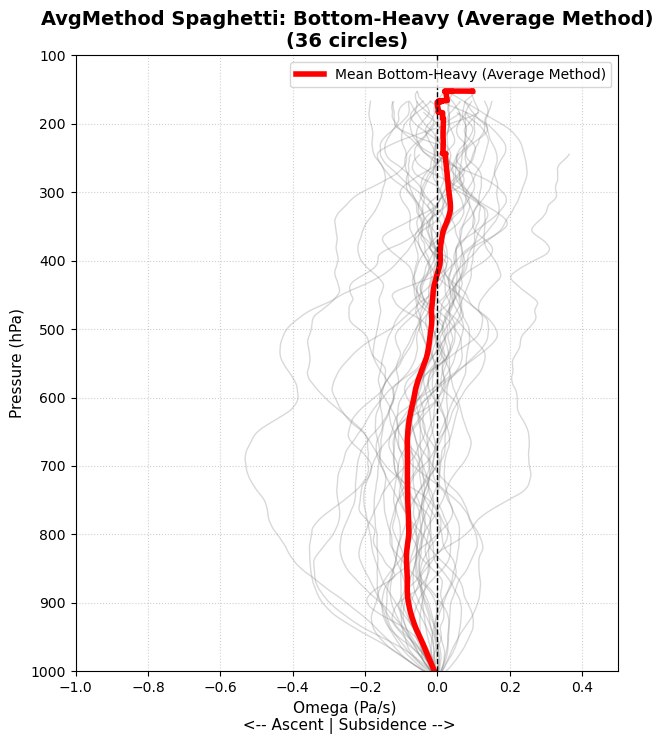

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Grid_Bottom-Heavy_Average_Method.png


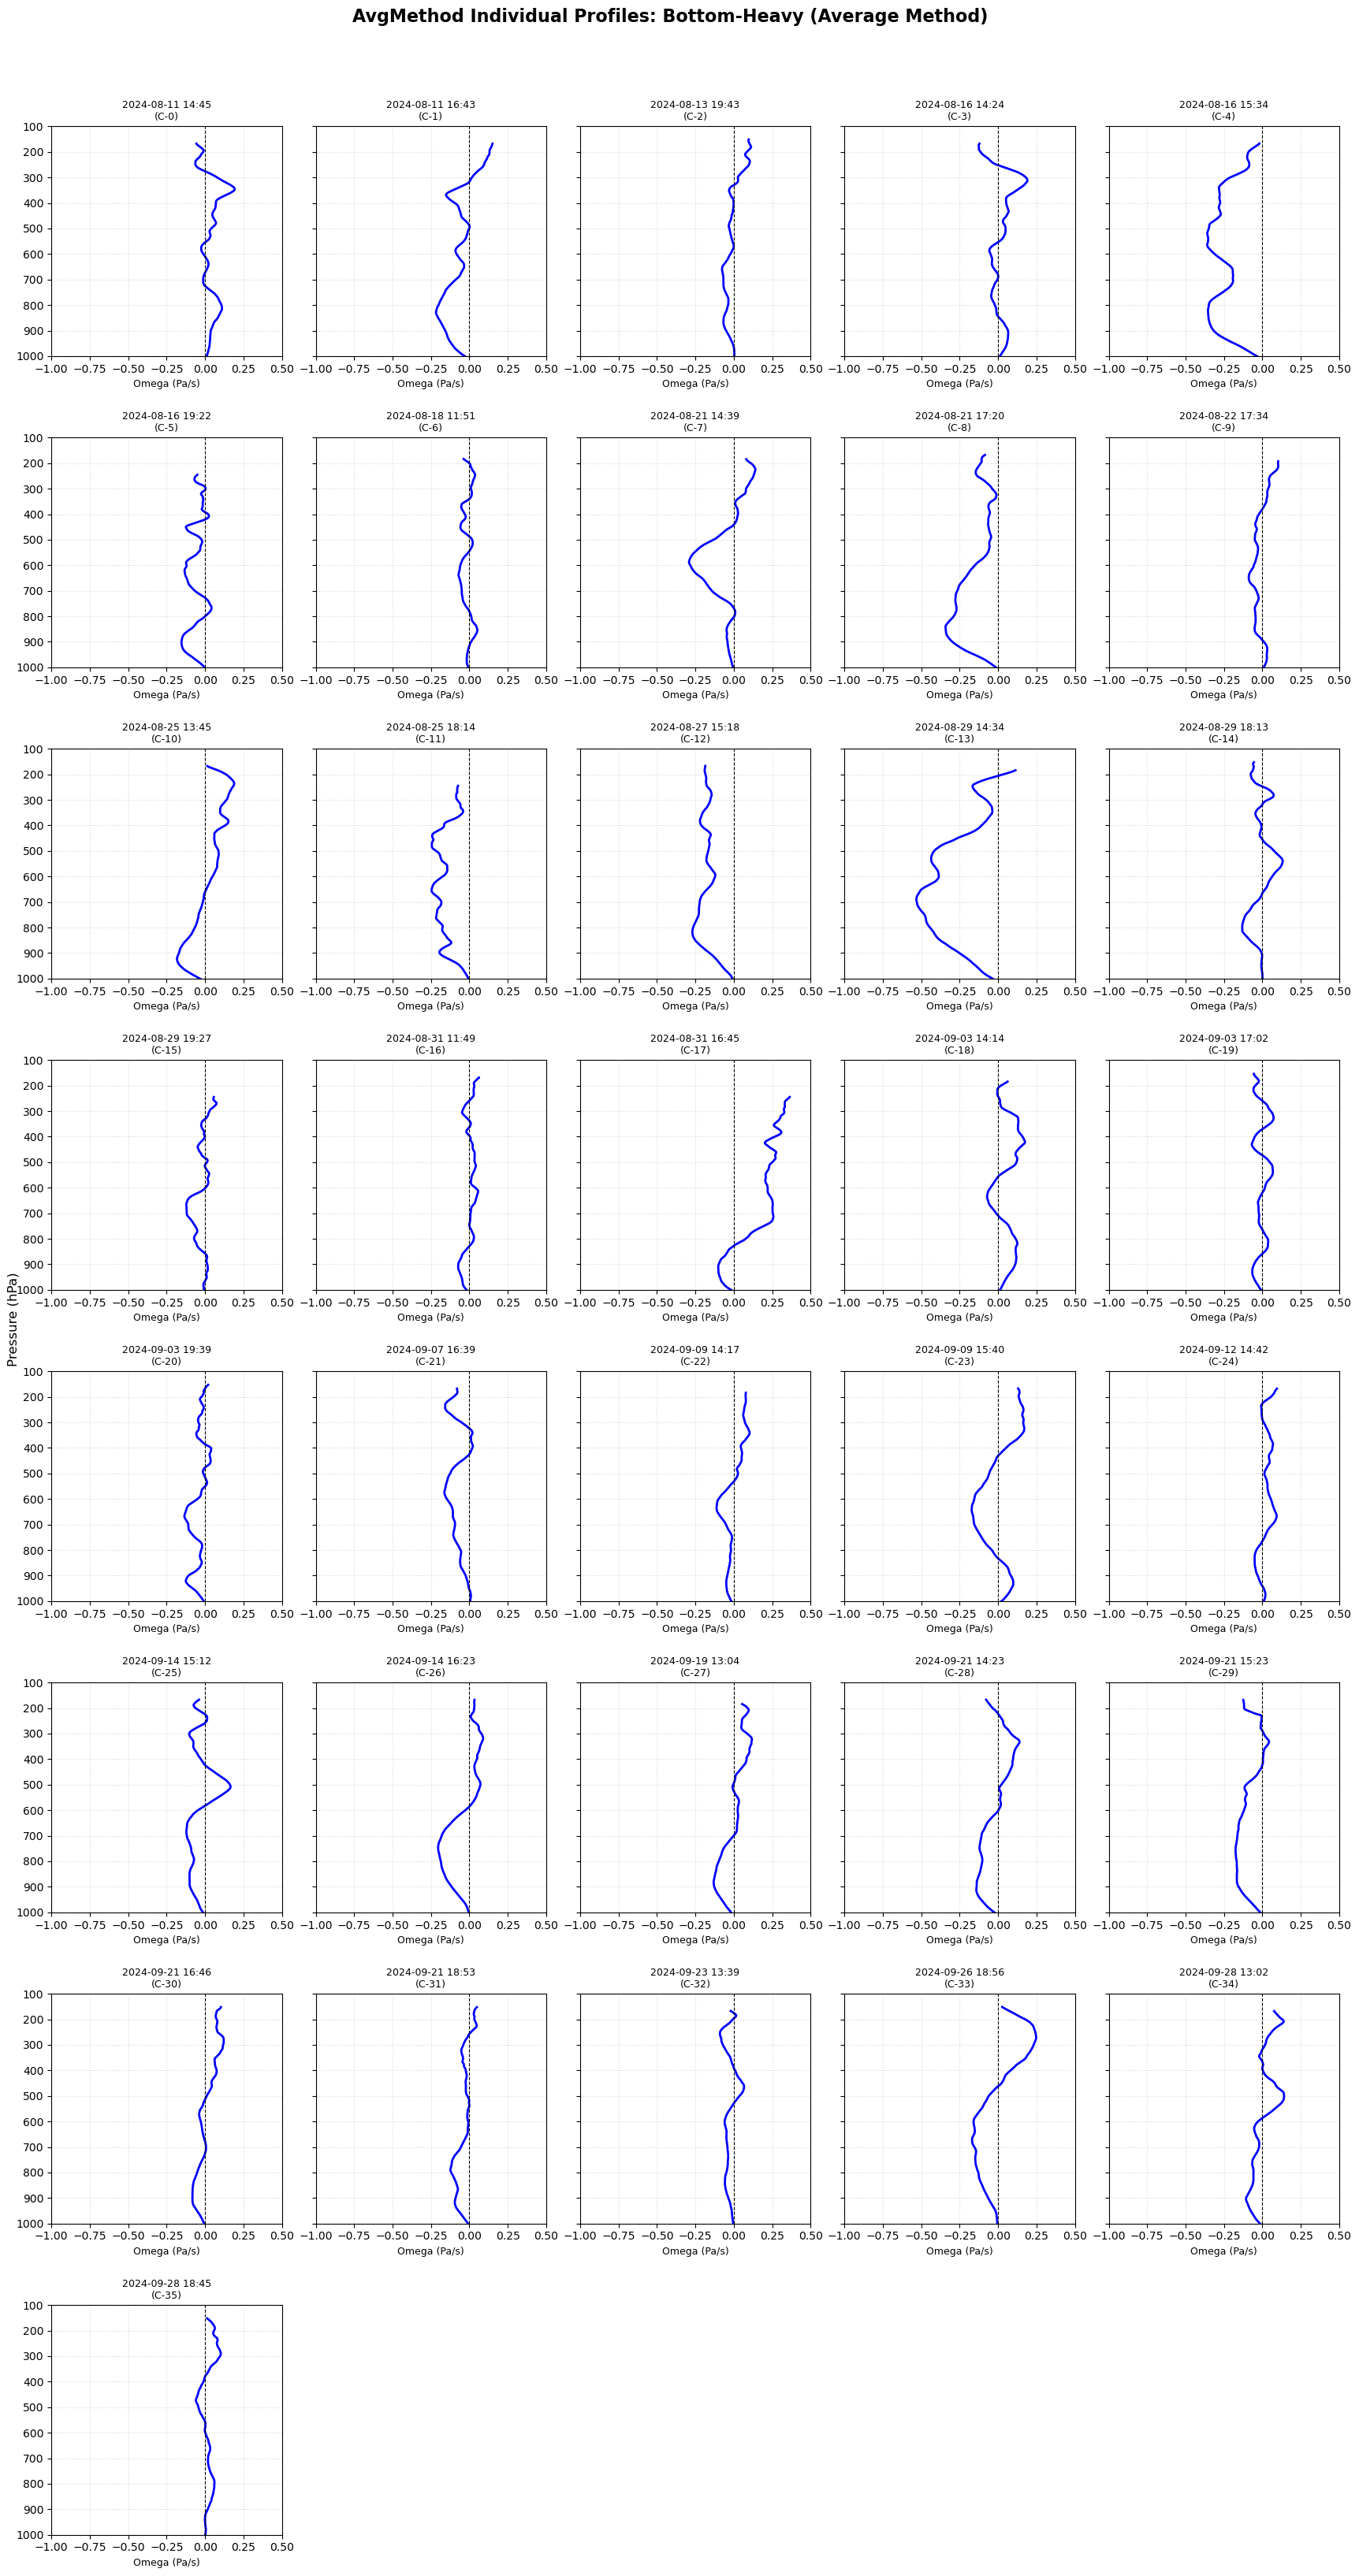


GENERATING AND SAVING PLOTS FOR [AVGMETHOD] REGIME: SUPPRESSED / WEAK
Total Circles: 22

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Spaghetti_Suppressed_Weak.png


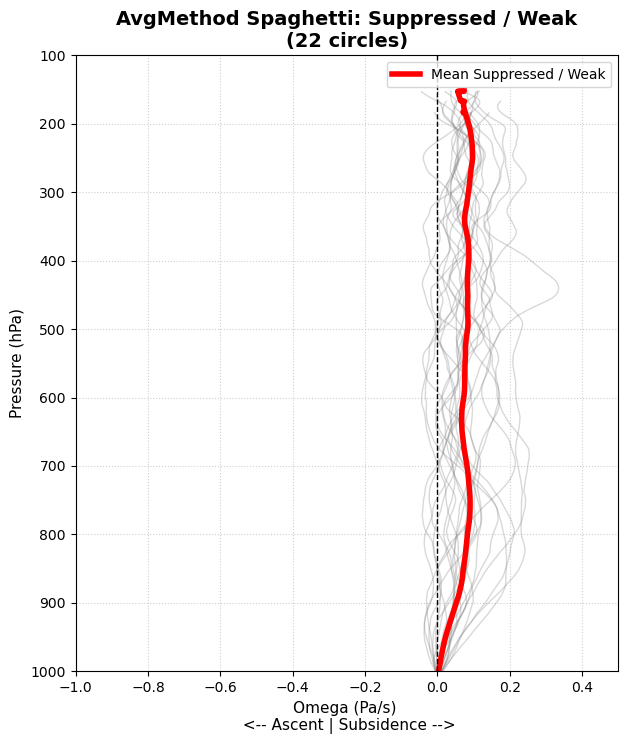

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Grid_Suppressed_Weak.png


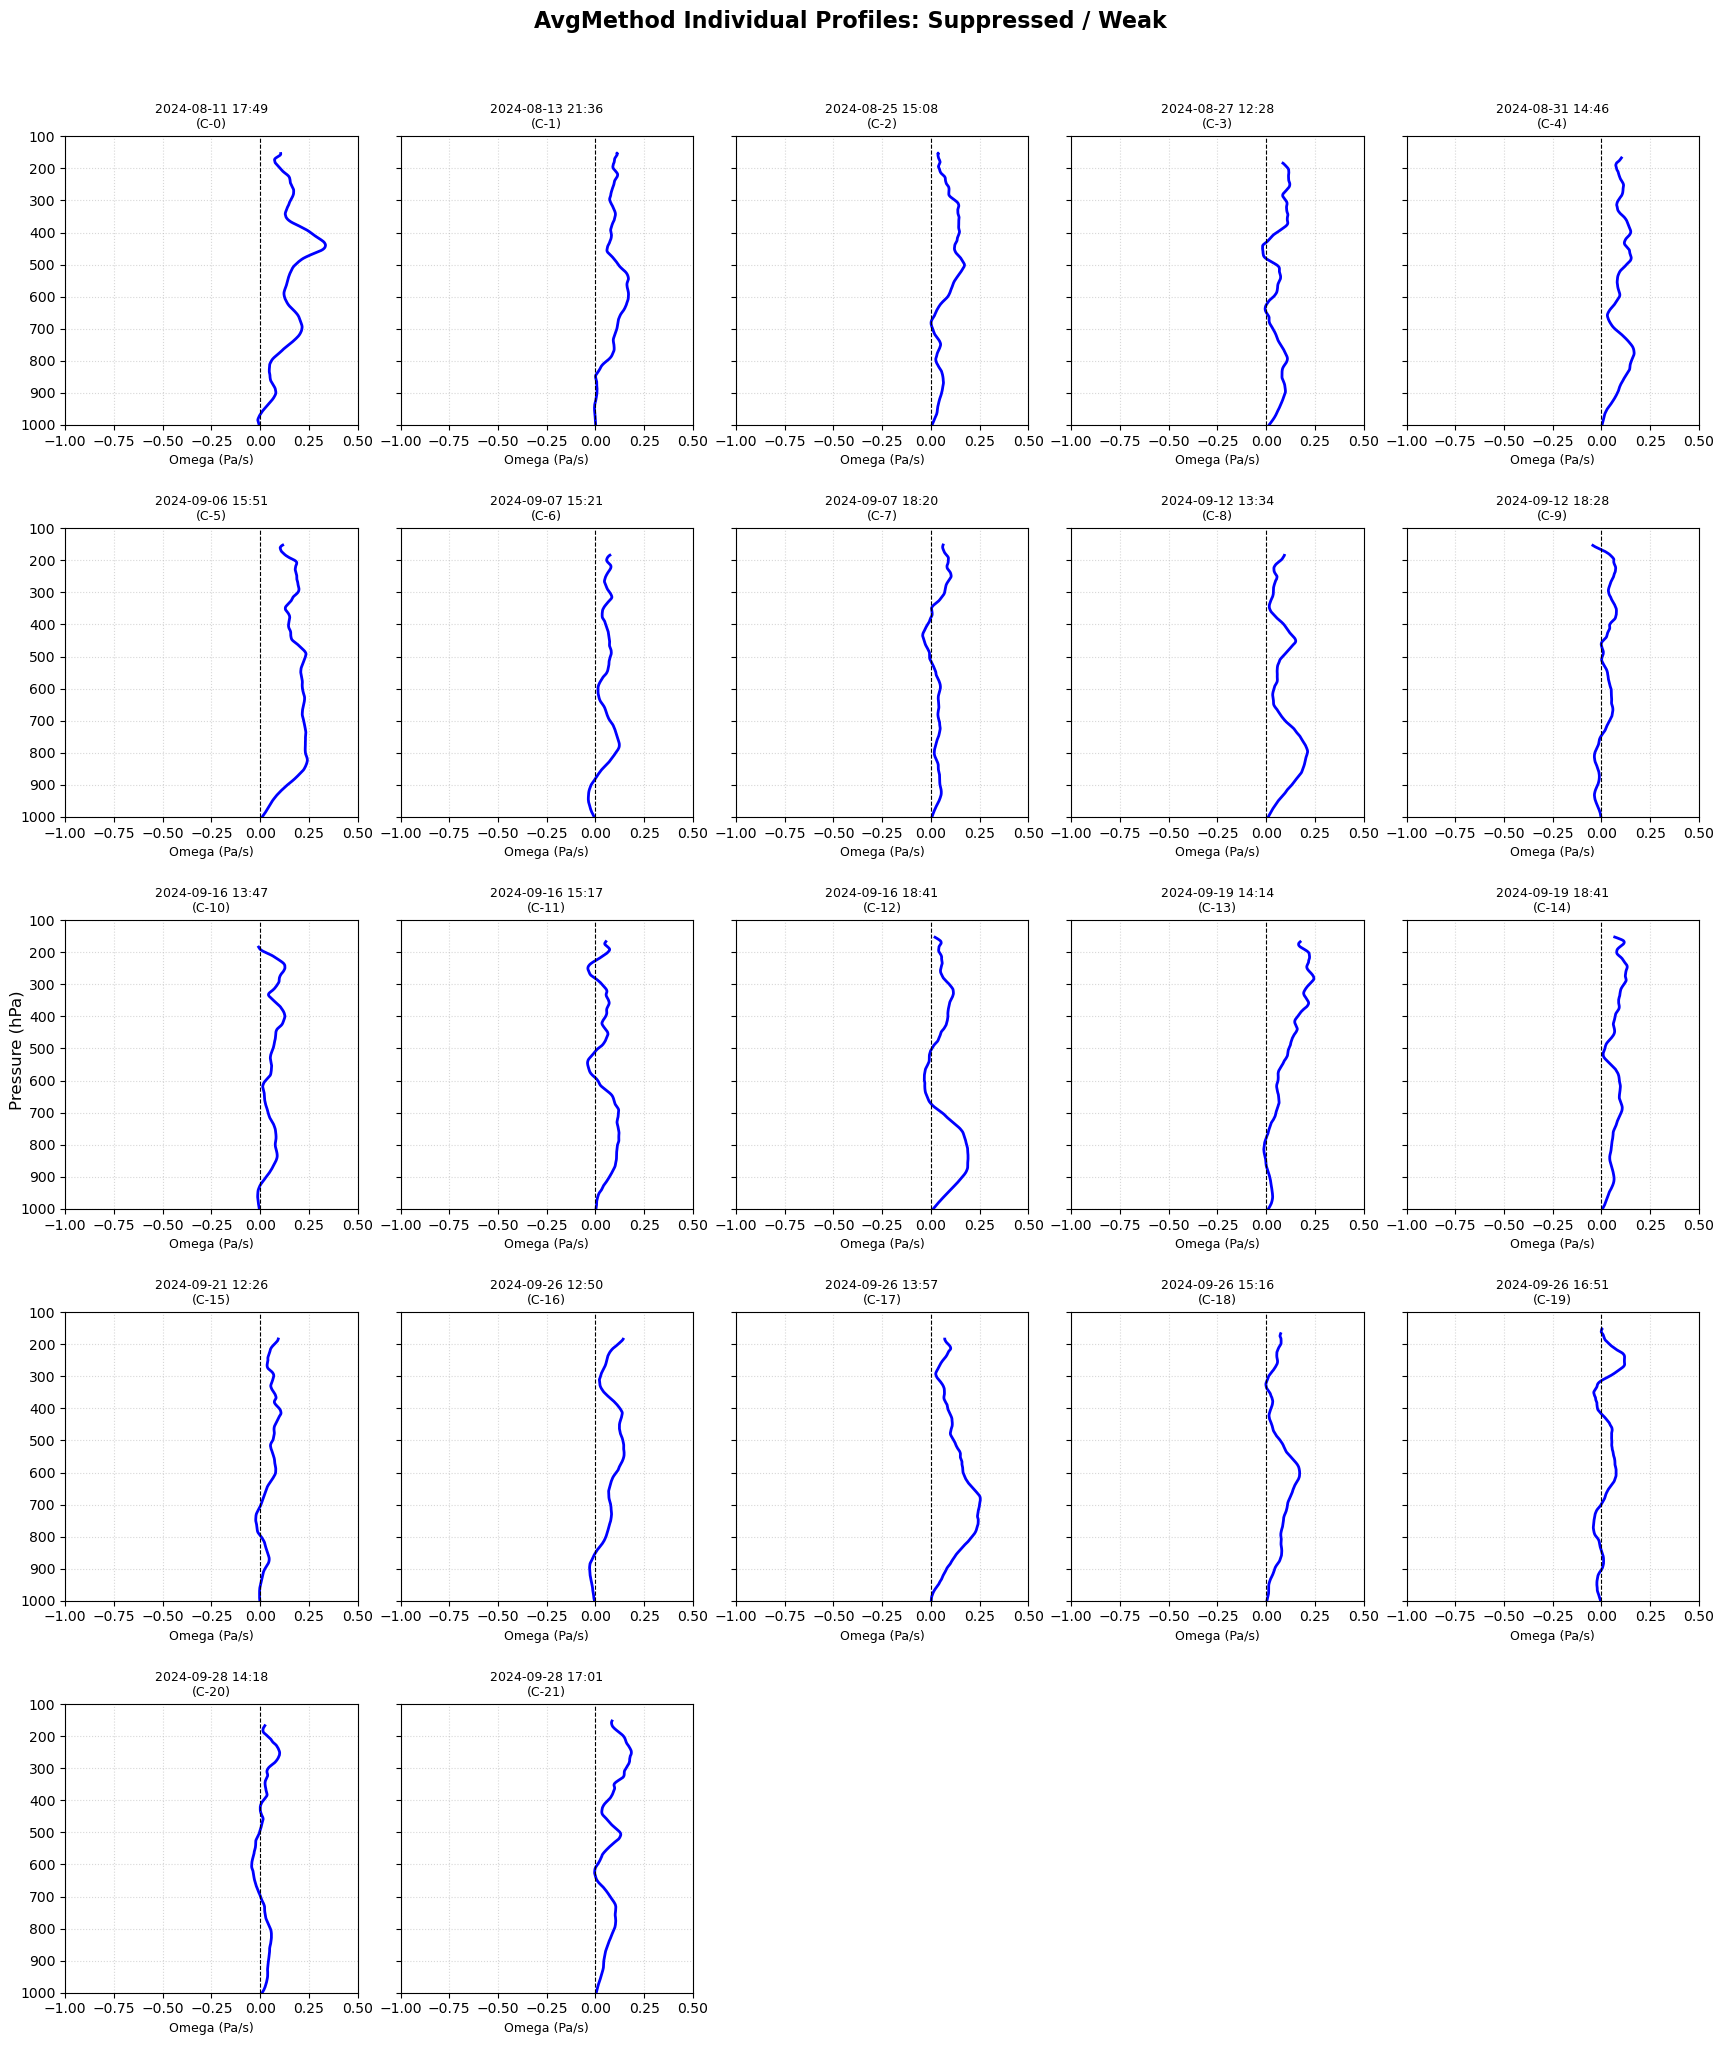


GENERATING AND SAVING PLOTS FOR [AVGMETHOD] REGIME: TOP-HEAVY (AVERAGE METHOD)
Total Circles: 29

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Spaghetti_Top-Heavy_Average_Method.png


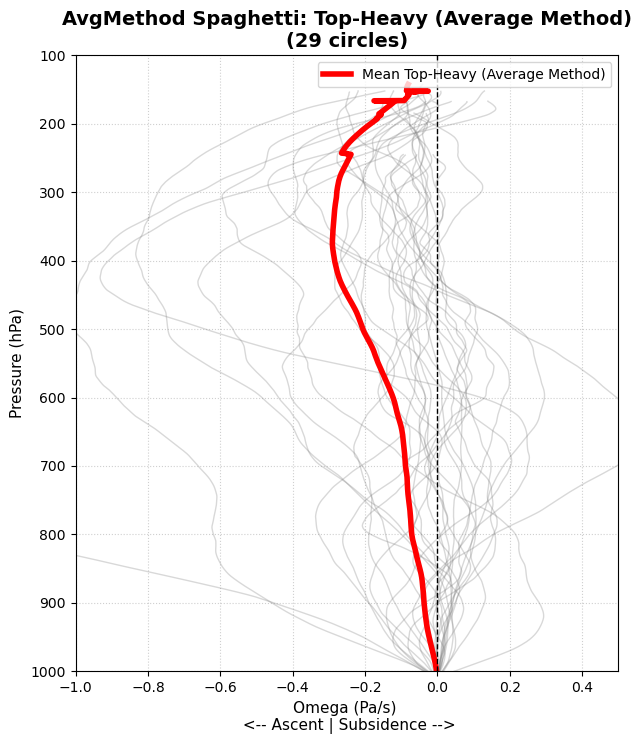

Saved: /home/565/zr7147/Proj/Plot-Figs/AvgMethod_Grid_Top-Heavy_Average_Method.png


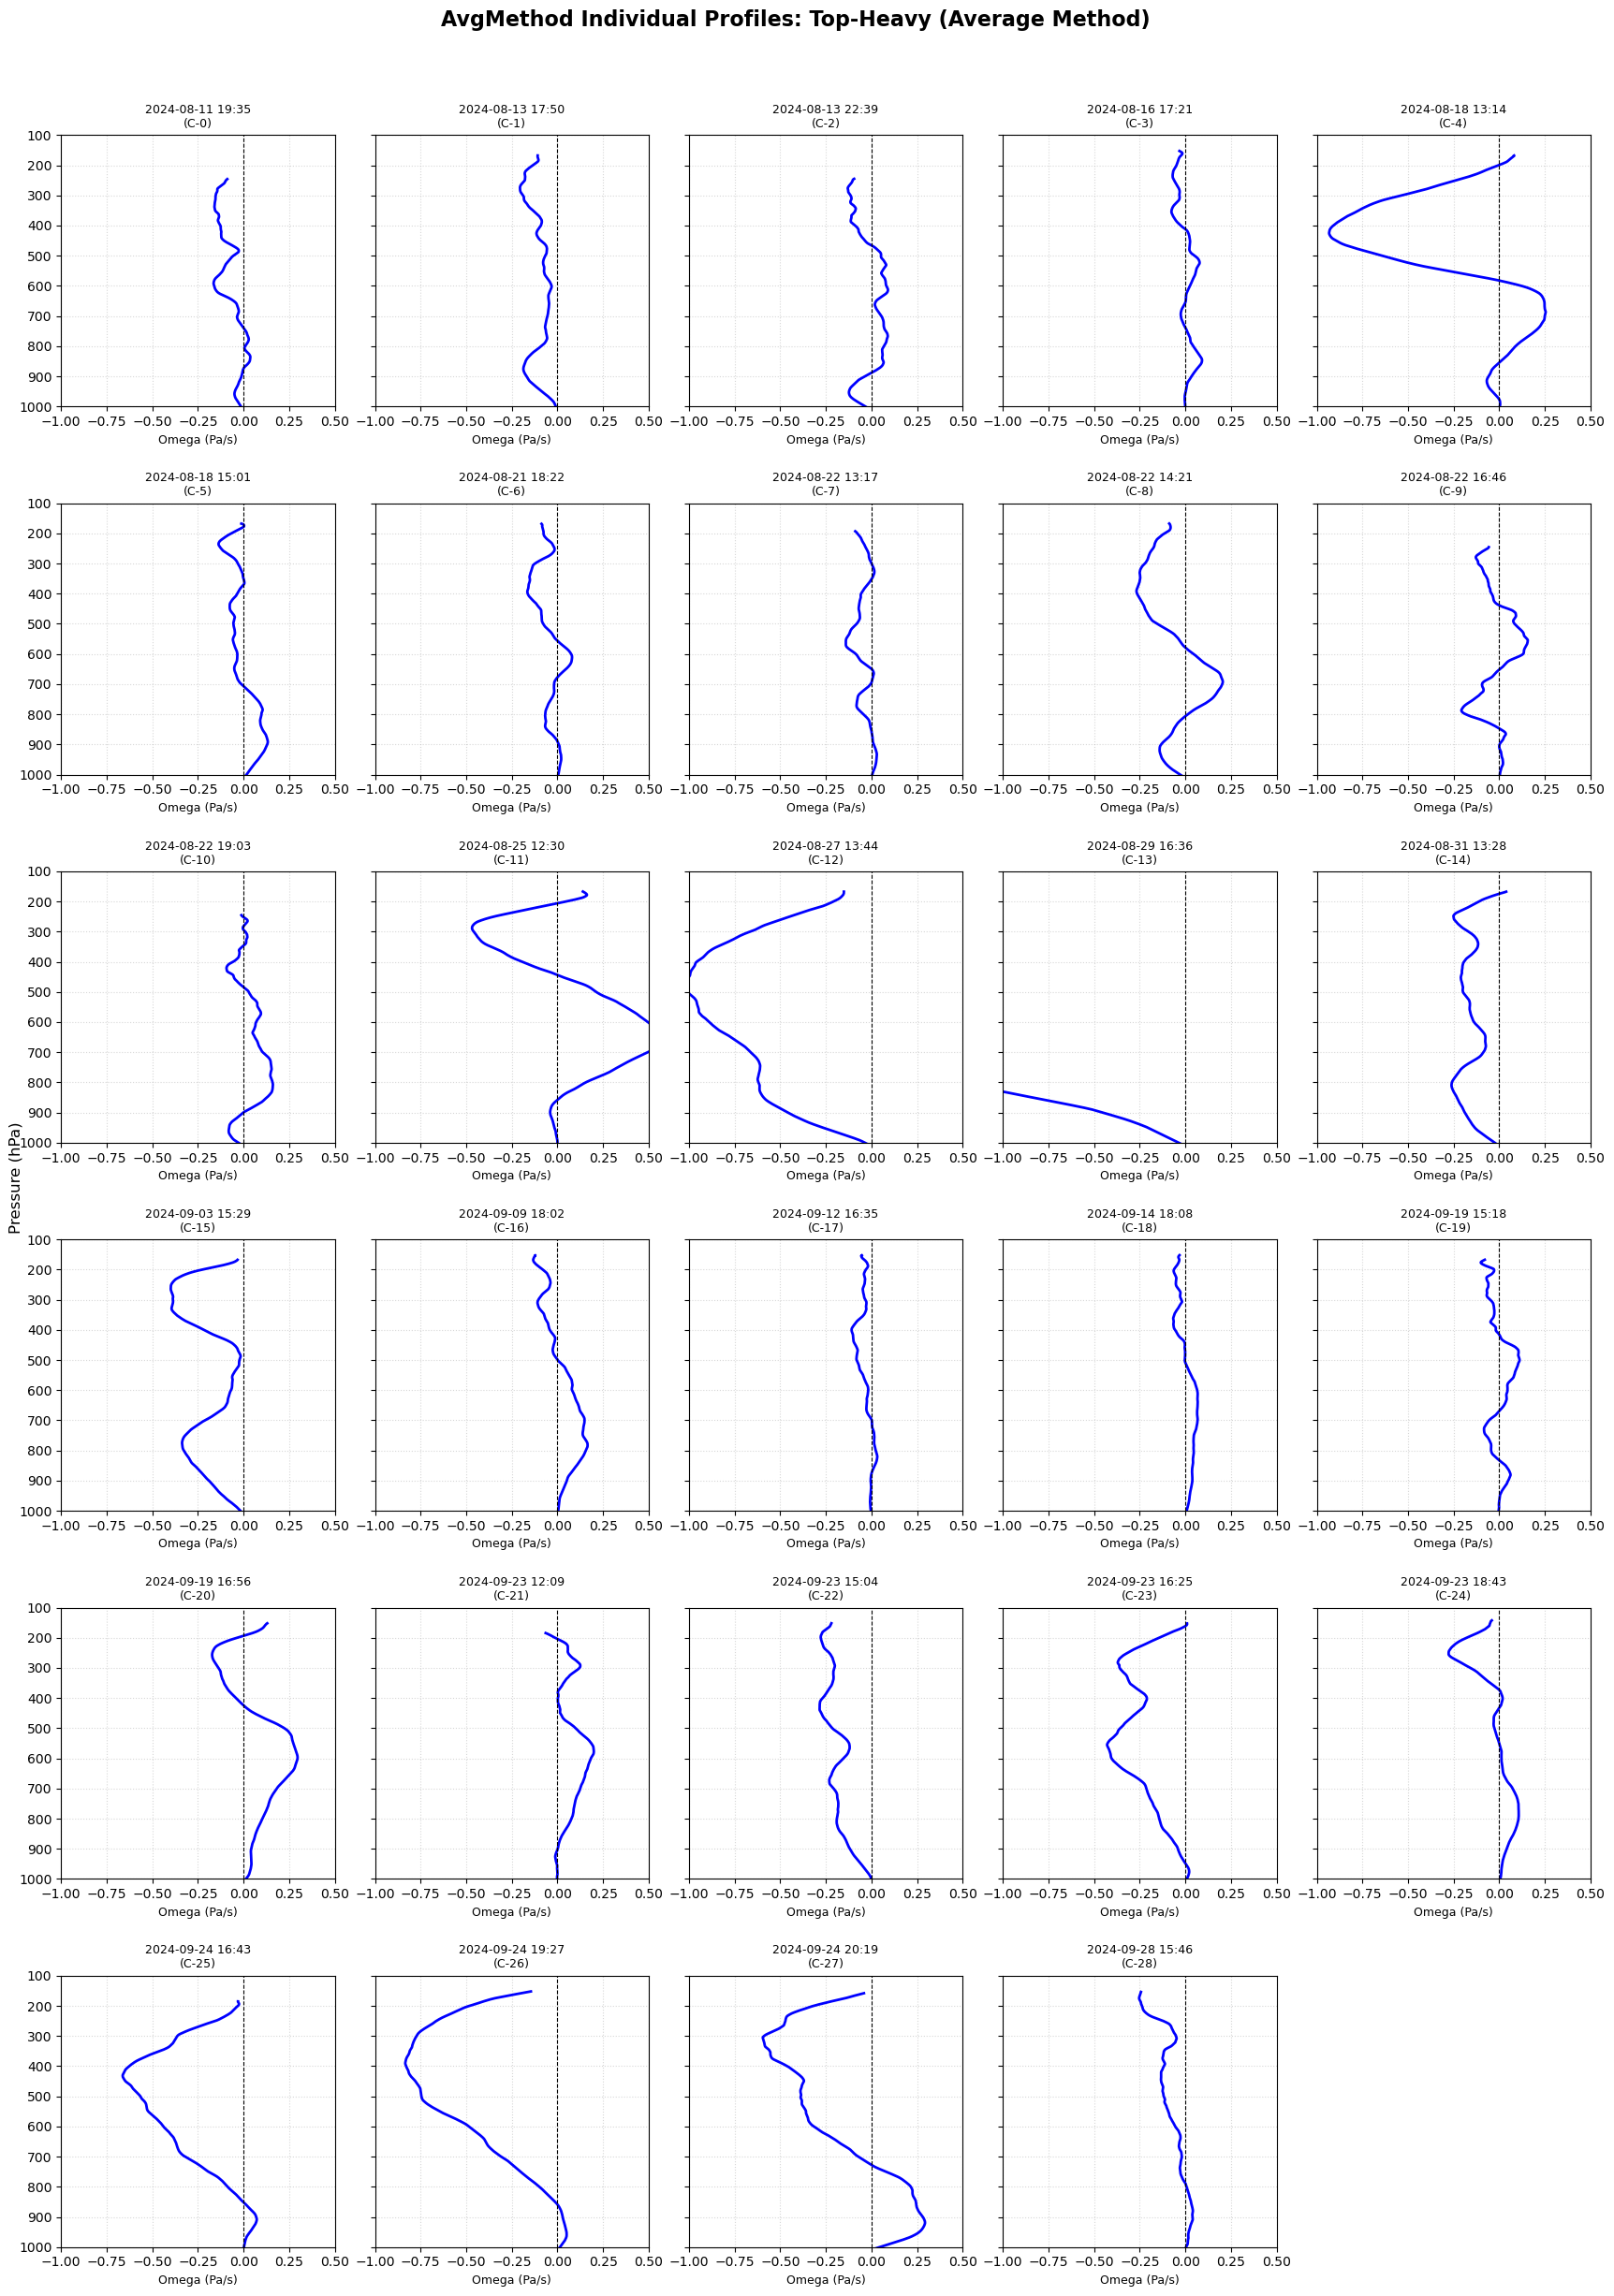

In [7]:
# 1. Define your exact Gadi output directory
output_dir = "/home/565/zr7147/Proj/Plot-Figs"
os.makedirs(output_dir, exist_ok=True) 

# ---------------------------------------------------------
# 2. SELECT CATEGORIZATION MODE (TOGGLE HERE)
# ---------------------------------------------------------

# Option a: Evolutionary Bimodal (Singh & Li 2025 - Angle Method)
# mode_prefix = "Evolutionary"
# category_var = "category_evolutionary"

# Option b: Simple Average Method (Upper vs Lower Troposphere)
mode_prefix = "AvgMethod"
category_var = "category_avg"


# Get a list of unique categories using your selected toggle, skipping "Missing Data"
valid_categories = [cat for cat in np.unique(ds[category_var].values) if cat != "Missing Data"]

# Define consistent axes limits for fair comparison
x_limits = (-1.0, 0.5)
y_limits = (1000, 100) # Pressure in hPa.

# Loop through each category
for cat in valid_categories:
    
    # Create a safe filename (e.g., removing spaces and slashes)
    safe_cat_name = str(cat).replace(" / ", "_").replace(" ", "_").replace("(", "").replace(")", "")
    
    # Filter data for this specific category using the toggled variable
    cat_mask = ds[category_var] == cat
    ds_cat = ds.isel(circle=cat_mask)
    
    circle_indices = ds_cat.circle.values
    n_circles = len(circle_indices)
    
    print(f"\n{'='*60}")
    print(f"GENERATING AND SAVING PLOTS FOR [{mode_prefix.upper()}] REGIME: {str(cat).upper()}")
    print(f"Total Circles: {n_circles}")
    print(f"{'='*60}\n")
    
    # ---------------------------------------------------------
    # PLOT TYPE 1: THE "SPAGHETTI" PLOT
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(7, 8))
    
    for c in circle_indices:
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100 
        ax1.plot(profile, pressure, color='gray', alpha=0.3, linewidth=1)
        
    mean_profile = ds_cat['omega'].mean(dim='circle')
    mean_pressure = ds_cat['p_mean'].mean(dim='circle') / 100
    
    ax1.plot(mean_profile, mean_pressure, color='red', linewidth=4, label=f'Mean {cat}')
    
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlim(x_limits)
    ax1.set_ylim(y_limits) 
    
    ax1.set_xlabel('Omega (Pa/s) \n <-- Ascent | Subsidence -->', fontsize=11)
    ax1.set_ylabel('Pressure (hPa)', fontsize=11)
    ax1.set_title(f'{mode_prefix} Spaghetti: {cat}\n({n_circles} circles)', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Save Spaghetti Plot with Mode Prefix
    fig1_path = os.path.join(output_dir, f'{mode_prefix}_Spaghetti_{safe_cat_name}.png')
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight') 
    print(f"Saved: {fig1_path}")
    
    plt.show()
    
    # ---------------------------------------------------------
    # PLOT TYPE 2: THE INDIVIDUAL GRID PLOTS
    # ---------------------------------------------------------
    cols = 5
    rows = math.ceil(n_circles / cols)
    
    # Ensure we don't crash if there are zero or few circles
    if n_circles > 0:
        fig2, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*4), sharex=True, sharey=True)
        if n_circles == 1: axes = [axes] # Handle case with only 1 circle
        else: axes = axes.flatten()
        
        for i, c in enumerate(circle_indices):
            profile = ds_cat['omega'].sel(circle=c)
            pressure = ds_cat['p_mean'].sel(circle=c) / 100
            
            raw_time = ds_cat['circle_time'].sel(circle=c).values
            datetime_str = pd.Timestamp(raw_time).strftime('%Y-%m-%d %H:%M')
            
            axes[i].plot(profile, pressure, color='blue', linewidth=2)
            axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)
            
            axes[i].set_title(f'{datetime_str}\n(C-{c})', fontsize=9) 
            axes[i].grid(True, linestyle=':', alpha=0.5)
            axes[i].tick_params(labelbottom=True) 
            axes[i].set_xlabel('Omega (Pa/s)', fontsize=9)
            
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        axes[0].set_xlim(x_limits)
        axes[0].set_ylim(y_limits)
        
        fig2.suptitle(f'{mode_prefix} Individual Profiles: {cat}', fontsize=16, fontweight='bold', y=1.02)
        fig2.supylabel('Pressure (hPa)', fontsize=12)
        
        plt.tight_layout(h_pad=2.0)
        
        # Save Grid Plot with Mode Prefix
        fig2_path = os.path.join(output_dir, f'{mode_prefix}_Grid_{safe_cat_name}.png')
        fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {fig2_path}")
        
        plt.show()